# 04 — Graph Attention Networks (GAT)

Graph Attention Networks learn **how strongly each neighbor should contribute** to a node update.

The progression is:

**Neighbor importance** → **Attention score** → **Softmax normalization** → **Weighted aggregation** → **Multi-head attention** → **Cora GAT**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.set_printoptions(precision=4,suppress=True)
torch.manual_seed(42)

## 1. Why attention on graphs?

A mean aggregator gives all neighbors equal weight.

For three neighbors:

$$
\frac{1}{3},\frac{1}{3},\frac{1}{3}
$$

GAT instead learns:

$$
\alpha_{i1},\alpha_{i2},\alpha_{i3}
$$

with:

$$
\sum_{j\in\mathcal{N}(i)}\alpha_{ij}=1
$$

A larger $\alpha_{ij}$ means neighbor $j$ contributes more to the update of node $i$.

## 2. Unnormalized graph-attention score

Transform node features using $W$.

For connected nodes $i$ and $j$:

$$
e_{ij}
=
\operatorname{LeakyReLU}
\left(
a^T
[
Wh_i
\Vert
Wh_j
]
\right)
$$

Only nodes connected through the graph participate in the neighborhood attention calculation.

## 3. Normalize attention coefficients

For the neighbors of node $i$:

$$
\alpha_{ij}
=
\frac{\exp(e_{ij})}
{\sum_{k\in\mathcal{N}(i)}\exp(e_{ik})}
$$

Then aggregate:

$$
h_i'
=
\sigma
\left(
\sum_{j\in\mathcal{N}(i)}
\alpha_{ij}Wh_j
\right)
$$

## 4. Complete numerical attention example

For one center node and three neighbors, we calculate:

1. transformed features,
2. attention scores,
3. softmax coefficients,
4. weighted neighbor contributions,
5. the final aggregated representation.

In [2]:
h_i = np.array([1.0,0.5])
neighbors = np.array([
    [0.0,1.0],
    [1.0,1.0],
    [2.0,0.0]
])

W = np.array([
    [0.6,-0.2],
    [0.3,0.8]
])

a = np.array([0.5,-0.3,0.7,0.2])

Wh_i = W @ h_i
Wh_neighbors = (W @ neighbors.T).T

print("Wh_i:",Wh_i)
print()
print("Wh_neighbors:")
print(Wh_neighbors)

Wh_i: [0.5 0.7]

Wh_neighbors:
[[-0.2  0.8]
 [ 0.4  1.1]
 [ 1.2  0.6]]


In [3]:
def leaky_relu(x,negative_slope=0.2):
    return np.where(x >= 0,x,negative_slope*x)

scores = []

for Wh_j in Wh_neighbors:
    pair = np.concatenate([Wh_i,Wh_j])
    score = leaky_relu(a @ pair)
    scores.append(score)

scores = np.array(scores)
attention = np.exp(scores-scores.max())
attention = attention/attention.sum()

weighted_neighbors = attention[:,None]*Wh_neighbors
aggregated = weighted_neighbors.sum(axis=0)

print("Raw attention scores:",scores)
print("Normalized coefficients:",attention)
print("Coefficient sum:",attention.sum())
print()
print("Weighted contributions:")
print(weighted_neighbors)
print()
print("Aggregated representation:",aggregated)

Raw attention scores: [0.06 0.54 1.  ]
Normalized coefficients: [0.1932 0.3122 0.4946]
Coefficient sum: 0.9999999999999999

Weighted contributions:
[[-0.0386  0.1546]
 [ 0.1249  0.3434]
 [ 0.5935  0.2967]]

Aggregated representation: [0.6797 0.7948]


## 5. Visualize the calculated neighbor importance

This plot is directly tied to the numerical calculation above.

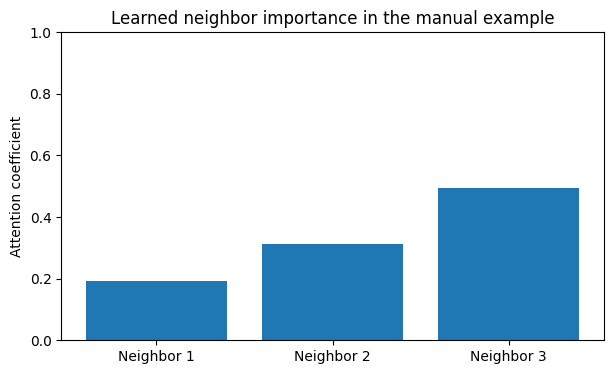

In [4]:
neighbor_names = ["Neighbor 1","Neighbor 2","Neighbor 3"]

plt.figure(figsize=(7,4))
plt.bar(neighbor_names,attention)
plt.ylabel("Attention coefficient")
plt.title("Learned neighbor importance in the manual example")
plt.ylim(0,1)
plt.show()

## 6. Multi-head graph attention

GAT commonly uses multiple attention heads.

For head $k$:

$$
h_i'^{(k)}
=
\sigma
\left(
\sum_{j\in\mathcal{N}(i)}
\alpha_{ij}^{(k)}W^{(k)}h_j
\right)
$$

Intermediate heads are often concatenated. Final heads may be averaged or combined without concatenation.

## 7. GAT on Cora

In [5]:
# Uncomment in Google Colab if needed:
!pip -q install torch-geometric

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv

dataset = Planetoid(root="data/Planetoid",name="Cora")
data = dataset[0]

print(data)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 569.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.6 MB/s eta 0:00:00


Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


## 8. Two-layer GAT classifier

The first layer uses four attention heads. Their outputs are concatenated.

The second layer produces class logits.

In [6]:
class GAT(nn.Module):
    def __init__(self,in_dim,hidden_per_head,out_dim,heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim,hidden_per_head,heads=heads,dropout=0.6)
        self.gat2 = GATConv(hidden_per_head*heads,out_dim,heads=1,concat=False,dropout=0.6)

    def forward(self,x,edge_index,return_embedding=False):
        x = F.dropout(x,p=0.6,training=self.training)
        x = self.gat1(x,edge_index)
        x = F.elu(x)
        embedding = x
        x = F.dropout(x,p=0.6,training=self.training)
        x = self.gat2(x,edge_index)

        if return_embedding:
            return x,embedding

        return x

model = GAT(dataset.num_node_features,8,dataset.num_classes,heads=4)

## 9. Train the model

In [7]:
def accuracy_from_logits(logits,y,mask):
    pred = logits[mask].argmax(dim=1)
    return (pred == y[mask]).float().mean().item()

optimizer = torch.optim.Adam(model.parameters(),lr=0.005,weight_decay=5e-4)
history = {"loss":[],"train_acc":[],"val_acc":[]}

for epoch in range(250):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x,data.edge_index)
    loss = F.cross_entropy(logits[data.train_mask],data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        logits = model(data.x,data.edge_index)

    history["loss"].append(loss.item())
    history["train_acc"].append(accuracy_from_logits(logits,data.y,data.train_mask))
    history["val_acc"].append(accuracy_from_logits(logits,data.y,data.val_mask))

## 10. Training behavior

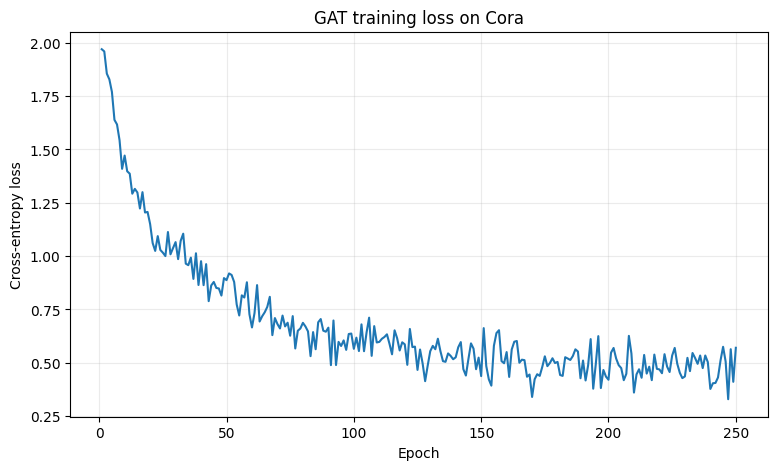

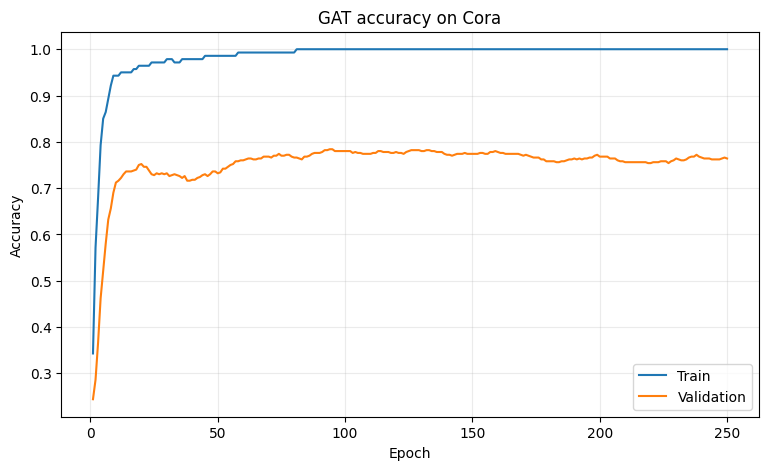

In [8]:
epochs = np.arange(1,len(history["loss"])+1)

plt.figure(figsize=(9,5))
plt.plot(epochs,history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("GAT training loss on Cora")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(epochs,history["train_acc"],label="Train")
plt.plot(epochs,history["val_acc"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GAT accuracy on Cora")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11. Test accuracy

In [9]:
model.eval()

with torch.no_grad():
    logits,embedding = model(data.x,data.edge_index,return_embedding=True)

test_acc = accuracy_from_logits(logits,data.y,data.test_mask)

print("GAT test accuracy:",test_acc)

GAT test accuracy: 0.777999997138977


## 12. Inspect actual learned attention weights

PyTorch Geometric can return edge-level attention coefficients from a trained `GATConv` layer.

The following cells inspect the incoming neighbors of a selected target node.

In [10]:
model.eval()

with torch.no_grad():
    _,(att_edge_index,alpha) = model.gat1(data.x,data.edge_index,return_attention_weights=True)

print("Attention edge-index shape:",att_edge_index.shape)
print("Attention tensor shape:",alpha.shape)

Attention edge-index shape: torch.Size([2, 13264])
Attention tensor shape: torch.Size([13264, 4])


In [11]:
target_node = 0
incoming = att_edge_index[1] == target_node

source_nodes = att_edge_index[0,incoming].cpu().numpy()
incoming_alpha = alpha[incoming].mean(dim=1).cpu().numpy()

attention_table = pd.DataFrame({
    "Source node":source_nodes,
    "Mean attention across heads":incoming_alpha
}).sort_values("Mean attention across heads",ascending=False)

print(attention_table.head(10))

   Source node  Mean attention across heads
3            0                     0.289547
1         1862                     0.266738
2         2582                     0.227639
0          633                     0.216076


## 13. Strongest learned incoming attention weights

This plot reflects learned model behavior rather than a decorative architecture diagram.

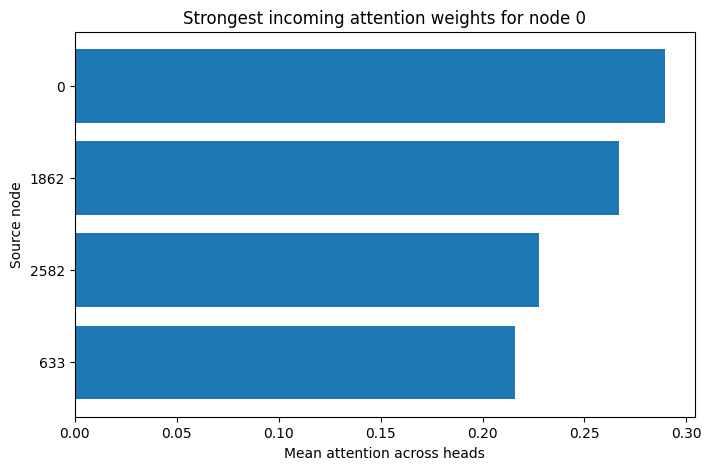

In [12]:
top = attention_table.head(10).sort_values("Mean attention across heads")

plt.figure(figsize=(8,5))
plt.barh(top["Source node"].astype(str),top["Mean attention across heads"])
plt.xlabel("Mean attention across heads")
plt.ylabel("Source node")
plt.title(f"Strongest incoming attention weights for node {target_node}")
plt.show()

## 14. GCN vs GraphSAGE vs GAT

| Model | Neighbor weighting | Main distinguishing idea |
|---|---|---|
| GCN | Degree-normalized structural weights | Normalized graph convolution |
| GraphSAGE | Aggregation such as mean | Inductive neighborhood aggregation |
| GAT | Learned attention coefficients | Adaptive neighbor importance |

All three are message-passing networks. Their main difference is how they combine neighborhood information.

## 15. Key takeaways

1. GAT learns edge-specific neighbor importance.
2. Softmax normalizes attention within a node's neighborhood.
3. Multi-head attention provides multiple learned views of local connectivity.
4. Attention coefficients can be inspected after training.
5. GAT remains a message-passing network; attention changes the aggregation weights.
6. The next notebook moves from node prediction to graph-level and edge-level prediction.